<a href="https://colab.research.google.com/github/mrivassnj-svg/HCC_ITAI_1371_SPR26/blob/main/Module_05_Lab_Data_Preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 05 Lab - Data Preparation**Objective:** To learn and apply the most common data preparation techniques. Raw data is rarely ready for a machine learning model. This process, also called preprocessing, is one of the most critical steps in the entire ML workflow.**In this lab, you will write more of the code.** Read the explanations and then complete the tasks in the code cells.

## Part 1: Setup and Initial LookWe will continue using the Titanic dataset because it has the exact problems we need to solve: missing values and non-numeric data.

In [2]:
import pandas as pd
import numpy as np
# Load the dataset
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
# Let's look at the missing values
print("--- Missing Values Before Cleaning ---")
print(df.isnull().sum())

--- Missing Values Before Cleaning ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## Part 2: Handling Missing Values (Imputation)**Concept:** Most machine learning models cannot handle missing values (`NaN`). We must deal with them. Dropping the rows is an option, but you lose data. A better way is **imputation**, which means filling in the missing values with a calculated guess.Common imputation strategies:*   **Mean:** Fill with the average value. Good for normally distributed data.*   **Median:** Fill with the middle value. Better for skewed data or data with outliers (like `Fare`).*   **Mode:** Fill with the most frequent value. Used for categorical data.

### Task 1: Impute the 'Age' ColumnThe 'Age' column is missing many values. Since age can be skewed (e.g., by a few very old passengers), using the **median** is a robust choice.**Your Task:** Calculate the median of the 'Age' column and use the `.fillna()` method to replace the missing values.

In [9]:
# Step 1: Find the middle (median) age
age_median = df["Age"].median()

# Step 2: Replace missing ages with that value
df["Age"] = df["Age"].fillna(age_median)

# Step 3: Check that no missing values remain
print("Remaining missing values in Age column:")
print(df["Age"].isna().sum())

Remaining missing values in Age column:
0


## Part 3: Encoding Categorical Features**Concept:** Machine learning models are mathematical, so they need numbers, not text. We need to convert categorical columns (like 'Sex' and 'Embarked') into a numerical format. The most common method is **One-Hot Encoding**.One-Hot Encoding takes a column with `N` categories and turns it into `N` new columns, each with a `1` or `0`. For example, the 'Sex' column (`male`, `female`) becomes two new columns: `Sex_male` and `Sex_female`.Pandas has a convenient function called `pd.get_dummies()` that does this for us.

### Task 2: One-Hot Encode Categorical Columns**Your Task:** Use `pd.get_dummies()` to encode the 'Sex' and 'Embarked' columns. Make sure to drop the original columns after encoding.

In [13]:
# Convert text categories into numeric indicator columns
# drop_first=True avoids creating duplicate information
encoded_df = pd.get_dummies(
    df,
    columns=["Sex", "Embarked"],
    drop_first=True
)

# Show the updated dataset structure
print(encoded_df.head())



   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0      1      0   
2                             Heikkinen, Miss. Laina  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0      1      0   
4                           Allen, Mr. William Henry  35.0      0      0   

             Ticket     Fare Cabin  Sex_male  Embarked_Q  Embarked_S  
0         A/5 21171   7.2500   NaN      True       False        True  
1          PC 17599  71.2833   C85     False       False       False  
2  STON/O2. 3101282   7.9250   NaN     False       False        True  
3            113803  53.1000  C123     Fal

## Part 4: Feature Scaling**Concept:** Many models are sensitive to the scale of the features. For example, `Age` (from 0-80) and `Fare` (from 0-512) are on very different scales. This can cause the model to incorrectly believe that `Fare` is a more important feature simply because its values are larger.**Feature Scaling** solves this by putting all features on a similar scale. A common method is **Standardization** (`StandardScaler` in scikit-learn), which rescales the data to have a mean of 0 and a standard deviation of 1.**Important:** You only scale your numerical features, not your target variable or your newly encoded categorical columns.

### Task 3: Scale the 'Age' and 'Fare' Columns**Your Task:** Use `StandardScaler` from `sklearn.preprocessing` to scale the 'Age' and 'Fare' columns.

In [14]:
from sklearn.preprocessing import StandardScaler

# Create scaling object
standardizer = StandardScaler()

# Columns that need scaling
numeric_features = ["Age", "Fare"]

# Apply scaling (fit + transform in one step)
encoded_df[numeric_features] = standardizer.fit_transform(
    encoded_df[numeric_features]
)

# View results
print(encoded_df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name       Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris -0.565736      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  0.663861      1      0   
2                             Heikkinen, Miss. Laina -0.258337      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  0.433312      1      0   
4                           Allen, Mr. William Henry  0.433312      0      0   

             Ticket      Fare Cabin  Sex_male  Embarked_Q  Embarked_S  
0         A/5 21171 -0.502445   NaN      True       False        True  
1          PC 17599  0.786845   C85     False       False       False  
2  STON/O2. 3101282 -0.488854   NaN     False       False        True  
3            1

## 📝 Knowledge Check**Instructions:** Answer the following questions in this markdown cell.1.  **Why is it often better to impute missing values with the median instead of the mean?**2.  **Explain in your own words what One-Hot Encoding does and why it is necessary.**3.  **Would you need to apply Feature Scaling to a Decision Tree model?** Why or why not? (Hint: Think about how a Decision Tree makes its splits).**[ENTER YOUR ANSWERS HERE]**

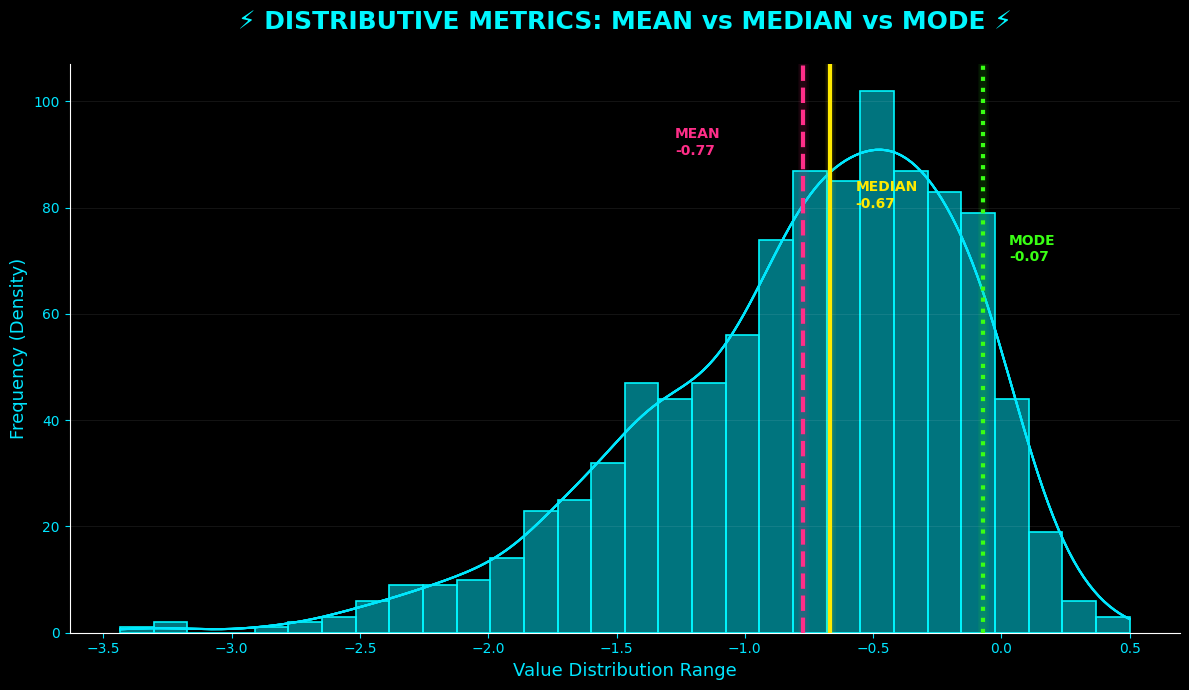

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skewnorm

# -----------------------------
# Generate Skewed Distribution
# -----------------------------
np.random.seed(42)
# Create a negatively skewed distribution
data = skewnorm.rvs(-5, size=1000)

mean_val = np.mean(data)
median_val = np.median(data)
mode_val = data[np.argmax(np.histogram(data, bins=30)[0])] # Approximate mode

# -----------------------------
# Styling Setup: Cyber-Glow Protocol
# -----------------------------
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(12, 7))

# Gradient-like layered histogram (for "Neon Glow" effect)
for alpha in [0.05, 0.08, 0.12]:
    sns.histplot(
        data,
        bins=30,
        kde=True,
        color="#00f7ff",
        alpha=alpha,
        linewidth=0,
        ax=ax
    )

# Main histogram layer (The "Core")
sns.histplot(
    data,
    bins=30,
    kde=True,
    color="#00e5ff",
    alpha=0.35,
    edgecolor="#00f7ff",
    linewidth=1.2,
    ax=ax
)

# -----------------------------
# Metrics: High-Visibility Lines
# -----------------------------
# Mean (Pink - Sensitive)
ax.axvline(mean_val, color="#ff2e88", linestyle="--", linewidth=3, label=f"Mean: {mean_val:.2f}")
# Median (Yellow - Robust)
ax.axvline(median_val, color="#ffea00", linestyle="-", linewidth=3, label=f"Median: {median_val:.2f}")
# Mode (Green - Peak)
ax.axvline(mode_val, color="#39ff14", linestyle=":", linewidth=3, label=f"Mode: {mode_val:.2f}")

# Glow effect for lines (Neon bloom)
for lw in [8, 6, 4]:
    ax.axvline(mean_val, color="#ff2e88", alpha=0.05, linewidth=lw)
    ax.axvline(median_val, color="#ffea00", alpha=0.05, linewidth=lw)
    ax.axvline(mode_val, color="#39ff14", alpha=0.05, linewidth=lw)

# -----------------------------
# HUD Annotations & Formatting
# -----------------------------
ax.text(mean_val - 0.5, 90, f"MEAN\n{mean_val:.2f}", color="#ff2e88", fontsize=10, weight="bold")
ax.text(median_val + 0.1, 80, f"MEDIAN\n{median_val:.2f}", color="#ffea00", fontsize=10, weight="bold")
ax.text(mode_val + 0.1, 70, f"MODE\n{mode_val:.2f}", color="#39ff14", fontsize=10, weight="bold")

ax.set_title("⚡ DISTRIBUTIVE METRICS: MEAN vs MEDIAN vs MODE ⚡",
             fontsize=18,
             color="#00f7ff",
             pad=25,
             weight="bold")

ax.set_xlabel("Value Distribution Range", fontsize=13, color="#00e5ff")
ax.set_ylabel("Frequency (Density)", fontsize=13, color="#00e5ff")

ax.tick_params(colors="#00e5ff")
ax.grid(axis="y", alpha=0.08)

# Blade Runner aesthetic border removal
sns.despine()

plt.tight_layout()
plt.show()